# 2 · Beams and torsion

The Macaulay solver handles determinate and indeterminate beams with the same code. Theory:
[docs/beam_theory.md](../docs/beam_theory.md).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from structures import plotting as P

P.use_style()
DEG = np.pi / 180
MPA = 1e6
from structures.beam_theory import (Beam, Support, PointLoad, DistributedLoad, Couple,
                                    closed_form, i_section, thin_walled, bredt_batho,
                                    open_thin_walled)

In [2]:
L, EI, w = 2.0, 3.0e5, 800.0
s = Beam(L, EI).add(Support(0, "fixed"), Support(L), DistributedLoad(0, L, -w)).solve()
ref = closed_form.propped_cantilever_udl(w, L, EI)
print("reactions:", [(sup.kind, round(F, 3), round(M, 3)) for sup, F, M in s.reactions])
print(f"prop reaction {s.reactions[1][1]:.1f} N vs 3wL/8 = {ref['R_prop']:.1f} N")
x, v = s.extreme("deflection")
print(f"max deflection {-v*1e3:.4f} mm (down) at x = {x:.4f} m (closed form {ref['deflection']*1e3:.4f} mm at {ref['x_max']:.4f} m)")

reactions: [('fixed', 1000.0, 400.0), ('pin', 600.0, 0.0)]
prop reaction 600.0 N vs 3wL/8 = 600.0 N
max deflection 0.2311 mm (down) at x = 1.1570 m (closed form 0.2311 mm at 1.1569 m)


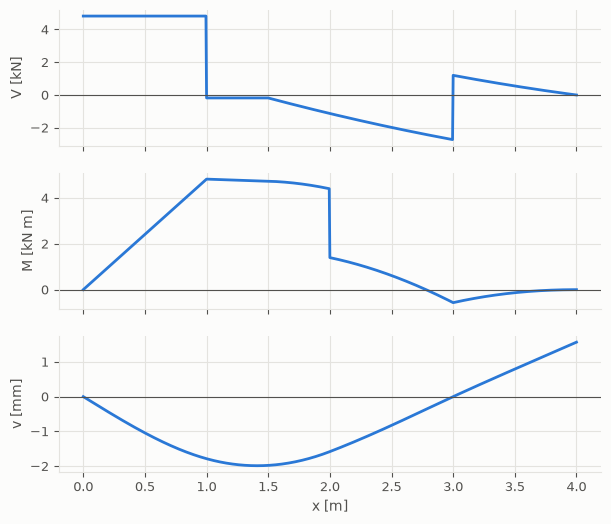

In [3]:
beam = Beam(4.0, 2.0e6).add(Support(0), Support(3.0), PointLoad(1.0, -5e3),
                            DistributedLoad(1.5, 4.0, -2e3, -1e3), Couple(2.0, 3e3))
sol = beam.solve()
x = np.linspace(0, 4, 801)
fig, axes = plt.subplots(3, 1, figsize=(7, 6), sharex=True)
for ax, f, lab in zip(axes, [sol.shear(x)/1e3, sol.moment(x)/1e3, sol.deflection(x)*1e3],
                      ["V [kN]", "M [kN m]", "v [mm]"]):
    ax.plot(x, f); ax.axhline(0, color=P.TEXT_MUTED, lw=0.8); ax.set_ylabel(lab)
axes[-1].set_xlabel("x [m]");

The couple at x = 2 m makes the bending moment jump, and the overhang beyond the support at 3 m hogs. Now torsion: a closed tube against the same tube slit open.

In [4]:
r, t, G, T = 0.05, 0.001, 27e9, 400.0
closed = bredt_batho(T, G, np.pi * r**2, [(2 * np.pi * r, t)])
opened = open_thin_walled(T, G, [(2 * np.pi * r, t)])
print(f"closed: tau = {closed.tau_max/MPA:.2f} MPa, twist = {closed.twist(1.0)/DEG:.4f} deg/m")
print(f"open:   tau = {opened.tau_max/MPA:.1f} MPa, twist = {opened.twist(1.0)/DEG:.1f} deg/m"
      "  <- far beyond yield: the slit tube cannot carry this torque")
print(f"stiffness ratio = {closed.J/opened.J:.0f} (3 r^2 / t^2 = {3*r**2/t**2:.0f})")

closed: tau = 25.46 MPa, twist = 1.0808 deg/m
open:   tau = 3819.7 MPa, twist = 8105.7 deg/m  <- far beyond yield: the slit tube cannot carry this torque
stiffness ratio = 7500 (3 r^2 / t^2 = 7500)
